In [27]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
SUBMISSION_DIR = Path("./submissions") 
BEST_PATH = SUBMISSION_DIR / "best" / "submission.csv"
NEW_PATH  = SUBMISSION_DIR / "latest" / "submission.csv"

best_submission = pd.read_csv(BEST_PATH)
new_submission  = pd.read_csv(NEW_PATH)

In [29]:
res_col = "preds_res"

In [30]:
df = pd.DataFrame({
    "best": best_submission[res_col],
    "new":  new_submission[res_col],
})
diff = df[df["best"] != df["new"]]

total = len(df)
num_changed = len(diff)

In [31]:
best_counts = diff["best"].value_counts().sort_index()
new_counts  = diff["new"].value_counts().sort_index()
classes = sorted(set(best_counts.index).union(set(new_counts.index)))
dist_df = pd.DataFrame({
    "best": pd.Series(best_counts, index=classes).fillna(0).astype(int),
    "new":  pd.Series(new_counts,  index=classes).fillna(0).astype(int),
})
display(dist_df)

,best,new
0,24,34
1,756,1300
2,1,0
3,757,528
4,838,514


In [32]:
conf = pd.crosstab(diff["best"], diff["new"])
conf = conf.reindex(index=classes, columns=classes, fill_value=0)
display(conf)


new,0,1,2,3,4
best,,,,,
0,0,13,0,2,9
1,13,0,0,342,401
2,0,0,0,1,0
3,1,652,0,0,104
4,20,635,0,183,0


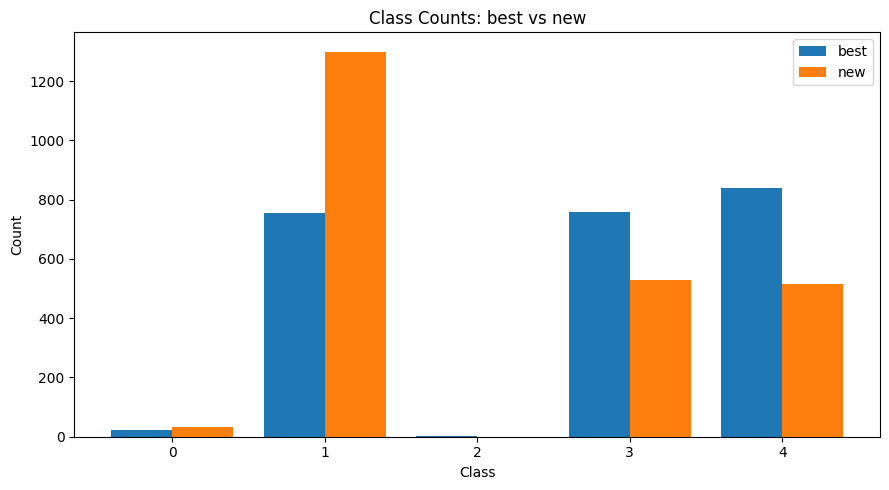

In [33]:
plt.figure(figsize=(9,5))
x = np.arange(len(classes))
w = 0.4
plt.bar(x - w/2, dist_df.loc[classes, "best"].values, width=w, label="best")
plt.bar(x + w/2, dist_df.loc[classes, "new"].values,  width=w, label="new")
plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Counts: best vs new")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
best_counts = df["best"].value_counts().sort_index()
new_counts  = df["new"].value_counts().sort_index()
classes = sorted(set(best_counts.index).union(set(new_counts.index)))
dist_df = pd.DataFrame({
    "best": pd.Series(best_counts, index=classes).fillna(0).astype(int),
    "new":  pd.Series(new_counts,  index=classes).fillna(0).astype(int),
})
display(dist_df)

,best,new
0,96,106
1,129540,130084
2,1,0
3,3309,3080
4,9729,9405
